<a href="https://colab.research.google.com/github/BossJimzy/3mtt-Capstone-Project/blob/main/CAPSTONE_PROJECT_RETAIL_CUSTOMER_SEGMENTATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

# REQUIRED LIBRARIES FOR THE RETAIL CUSTOMER SEGMENTATION  PROJECT

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# For Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# for Set styling
sns.set_style("whitegrid")
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully")

Libraries imported successfully


In [3]:

# Load the dataset (Alheri Supermarket Data)
file_path = '/content/drive/MyDrive/Credentials/3mttCapstonProject/AlheriSupermarketdata.csv'
df = pd.read_csv(file_path)

print(f"Loaded Successful")


Loaded Successful


In [4]:
# Data cleaning

# Check for missing values
print(f"\nMissing values per column:")
print(df.isnull().sum())

# Drop any rows with missing values (just in case)
df.dropna(inplace=True)
print(f"\nAfter dropping NaN: {len(df):,} transactions")

print("\nSummary of data:")
df.head(10)


Missing values per column:
CustomerID          0
InvoiceDate         0
ProductID           0
ProductName         0
Category            0
Quantity       275130
UnitPrice      275130
TotalPrice     275130
IsBulk              0
dtype: int64

After dropping NaN: 711,090 transactions

Summary of data:


,CustomerID,InvoiceDate,ProductID,ProductName,Category,Quantity,UnitPrice,TotalPrice,IsBulk
3,3390,2025-01-01,10,Eggs (crate of 30),Foodstuff,12.0,6800.0,81600.0,False
4,1494,2025-01-01,16,Indomie (carton of 24 packs),Beverages,4.0,9800.0,39200.0,False
5,1494,2025-01-01,22,Frozen Chicken Laps,Foodstuff,2.0,2000.0,4000.0,False
6,1494,2025-01-01,22,Frozen Chicken Laps,Foodstuff,2.0,2000.0,4000.0,False
7,1272,2025-01-01,16,Indomie (carton of 24 packs),Beverages,1.0,9800.0,9800.0,False
8,1272,2025-01-01,24,Frozen Mackerel (1kg),Foodstuff,3.0,6800.0,20400.0,False
10,1272,2025-01-01,11,Bread (500g loaf),Beverages,2.0,800.0,1600.0,False
11,3125,2025-01-01,15,Spaghetti (carton of 12 packs),Beverages,12.0,770.0,9240.0,True
12,3125,2025-01-01,37,Screen Protector,Phone Accessories,1.0,1500.0,1500.0,False
15,3110,2025-01-01,10,Eggs (crate of 30),Foodstuff,6.0,6800.0,40800.0,False


=== DATA OVERVIEW ===
Total transactions: 711,090
Total customers: 2,500
Total products: 40
Total revenue: ₦15,856,321,170.00
Average transaction value: ₦22298.61
Bulk purchases: 21,611 (3.0%)

=== CATEGORY ANALYSIS ===
                   Total Revenue  Avg Transaction  Transactions  \
Category                                                          
Foodstuff           7.786587e+09         28235.49        275773   
Household           3.893321e+09         35962.69        108260   
Beverages           2.283712e+09         12093.11        188844   
Electronics         9.263305e+08         26900.84         34435   
Clothing            4.148315e+08         12046.10         34437   
Baby Items          4.009332e+08         11487.40         34902   
Phone Accessories   1.506060e+08          4373.12         34439   

                   Unique Customers  
Category                             
Foodstuff                      2500  
Household                      2498  
Beverages               

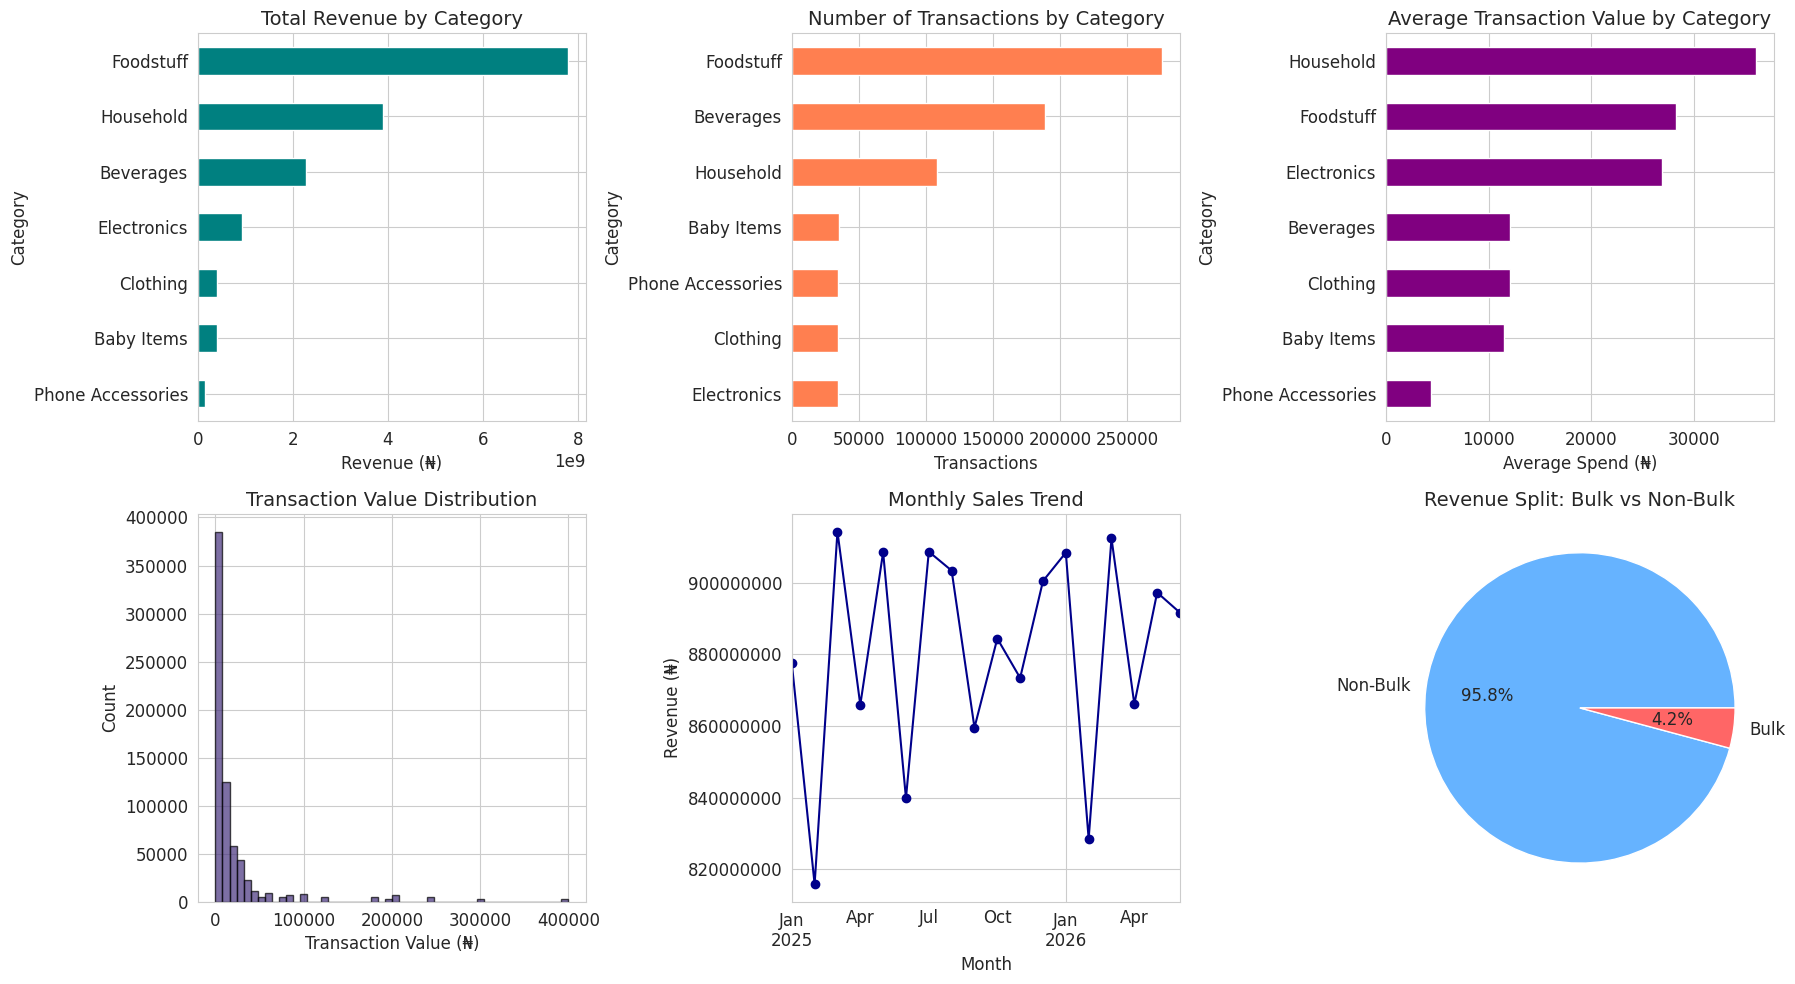

✅ EDA visualizations saved!


In [6]:
import pandas as pd

# EXPLORATORY DATA ANALYSIS (EDA)

# Ensure 'InvoiceDate' is a datetime object
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("=== DATA OVERVIEW ===")
print(f"Total transactions: {len(df):,}")
print(f"Total customers: {df['CustomerID'].nunique():,}")
print(f"Total products: {df['ProductID'].nunique():,}")
print(f"Total revenue: ₦{df['TotalPrice'].sum():,.2f}")
print(f"Average transaction value: ₦{df['TotalPrice'].mean():.2f}")
print(f"Bulk purchases: {df['IsBulk'].sum():,} ({df['IsBulk'].sum()/len(df)*100:.1f}%)")

# Category analysis
print("\n=== CATEGORY ANALYSIS ===")
category_stats = df.groupby('Category').agg({
    'TotalPrice': ['sum', 'mean', 'count'],
    'CustomerID': 'nunique'
}).round(2)
category_stats.columns = ['Total Revenue', 'Avg Transaction', 'Transactions', 'Unique Customers']
print(category_stats.sort_values('Total Revenue', ascending=False))

# Enhanced Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Revenue by Category (barh)
cat_rev = df.groupby('Category')['TotalPrice'].sum().sort_values(ascending=True)
cat_rev.plot(kind='barh', ax=axes[0,0], color='teal')
axes[0,0].set_title('Total Revenue by Category', fontsize=14)
axes[0,0].set_xlabel('Revenue (₦)')

# 2. Transaction Count by Category
cat_count = df.groupby('Category').size().sort_values(ascending=True)
cat_count.plot(kind='barh', ax=axes[0,1], color='coral')
axes[0,1].set_title('Number of Transactions by Category', fontsize=14)
axes[0,1].set_xlabel('Transactions')

# 3. Average Transaction Value by Category
cat_avg = df.groupby('Category')['TotalPrice'].mean().sort_values(ascending=True)
cat_avg.plot(kind='barh', ax=axes[0,2], color='purple')
axes[0,2].set_title('Average Transaction Value by Category', fontsize=14)
axes[0,2].set_xlabel('Average Spend (₦)')

# 4. Transaction Value Distribution
axes[1,0].hist(df['TotalPrice'], bins=50, edgecolor='black', alpha=0.7)
axes[1,0].set_title('Transaction Value Distribution', fontsize=14)
axes[1,0].set_xlabel('Transaction Value (₦)')
axes[1,0].set_ylabel('Count')
axes[1,0].ticklabel_format(style='plain', axis='x')

# 5. Monthly Sales Trend
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['TotalPrice'].sum()
monthly_sales.plot(kind='line', marker='o', ax=axes[1,1], color='darkblue')
axes[1,1].set_title('Monthly Sales Trend', fontsize=14)
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Revenue (₦)')
axes[1,1].ticklabel_format(style='plain', axis='y')

# 6. Bulk vs Non-Bulk Revenue
bulk_rev = df.groupby('IsBulk')['TotalPrice'].sum()
bulk_rev.index = ['Non-Bulk', 'Bulk']
bulk_rev.plot(kind='pie', ax=axes[1,2], autopct='%1.1f%%', colors=['#66b3ff', '#ff6666'])
axes[1,2].set_title('Revenue Split: Bulk vs Non-Bulk', fontsize=14)
axes[1,2].set_ylabel('')

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ EDA visualizations saved!")

In [ ]:
# RFM ANALYSIS + PRODUCT PREFERENCES

snapshot_date = df['InvoiceDate'].max() + timedelta(days=1)

# Per-customer RFM metrics
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'CustomerID': 'count',                                    # Frequency
    'TotalPrice': 'sum',                                      # Monetary
    'Quantity': 'sum',                                        # Total items
    'IsBulk': 'sum',                                          # Bulk count
    'Category': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',
    'ProductName': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
}).rename(columns={
    'InvoiceDate': 'Recency',
    'CustomerID': 'Frequency',
    'TotalPrice': 'Monetary',
    'Quantity': 'TotalItems',
    'IsBulk': 'BulkCount',
    'Category': 'PreferredCategory',
    'ProductName': 'PreferredProduct'
})

# Add average basket size
rfm['AvgBasketSize'] = rfm['TotalItems'] / rfm['Frequency']
rfm['BulkRatio'] = rfm['BulkCount'] / rfm['Frequency']  # fraction of bulk purchases

print("=== RFM METRICS ===")
print(f"Customers analyzed: {len(rfm):,}")
print(f"Average Recency: {rfm['Recency'].mean():.1f} days")
print(f"Average Frequency: {rfm['Frequency'].mean():.1f} purchases")
print(f"Average Monetary: ₦{rfm['Monetary'].mean():,.2f}")
print(f"Average Basket Size: {rfm['AvgBasketSize'].mean():.1f} items")

# RFM Scores (1-5)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print("\nRFM Score Distribution (Top 10):")
print(rfm['RFM_Score'].value_counts().head(10))

=== RFM METRICS ===
Customers analyzed: 2,500
Average Recency: 10.5 days
Average Frequency: 284.4 purchases
Average Monetary: ₦6,342,528.47
Average Basket Size: 3.9 items

RFM Score Distribution (Top 10):
RFM_Score
111    243
555    201
455    183
444    136
233    120
544    119
222    116
122    101
211    100
333     98
Name: count, dtype: int64


In [ ]:
# FEATURE ENGINEERING FOR CLUSTERING

# Log-transform Monetary to handle skew
rfm['Log_Monetary'] = np.log1p(rfm['Monetary'])

# We'll use Recency, Frequency, Log_Monetary (standard RFM)
# but can also include AvgBasketSize and BulkRatio for extra insight
features = ['Recency', 'Frequency', 'Log_Monetary']
X = rfm[features].copy()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled. Shape:", X_scaled.shape)

Features scaled. Shape: (2500, 3)


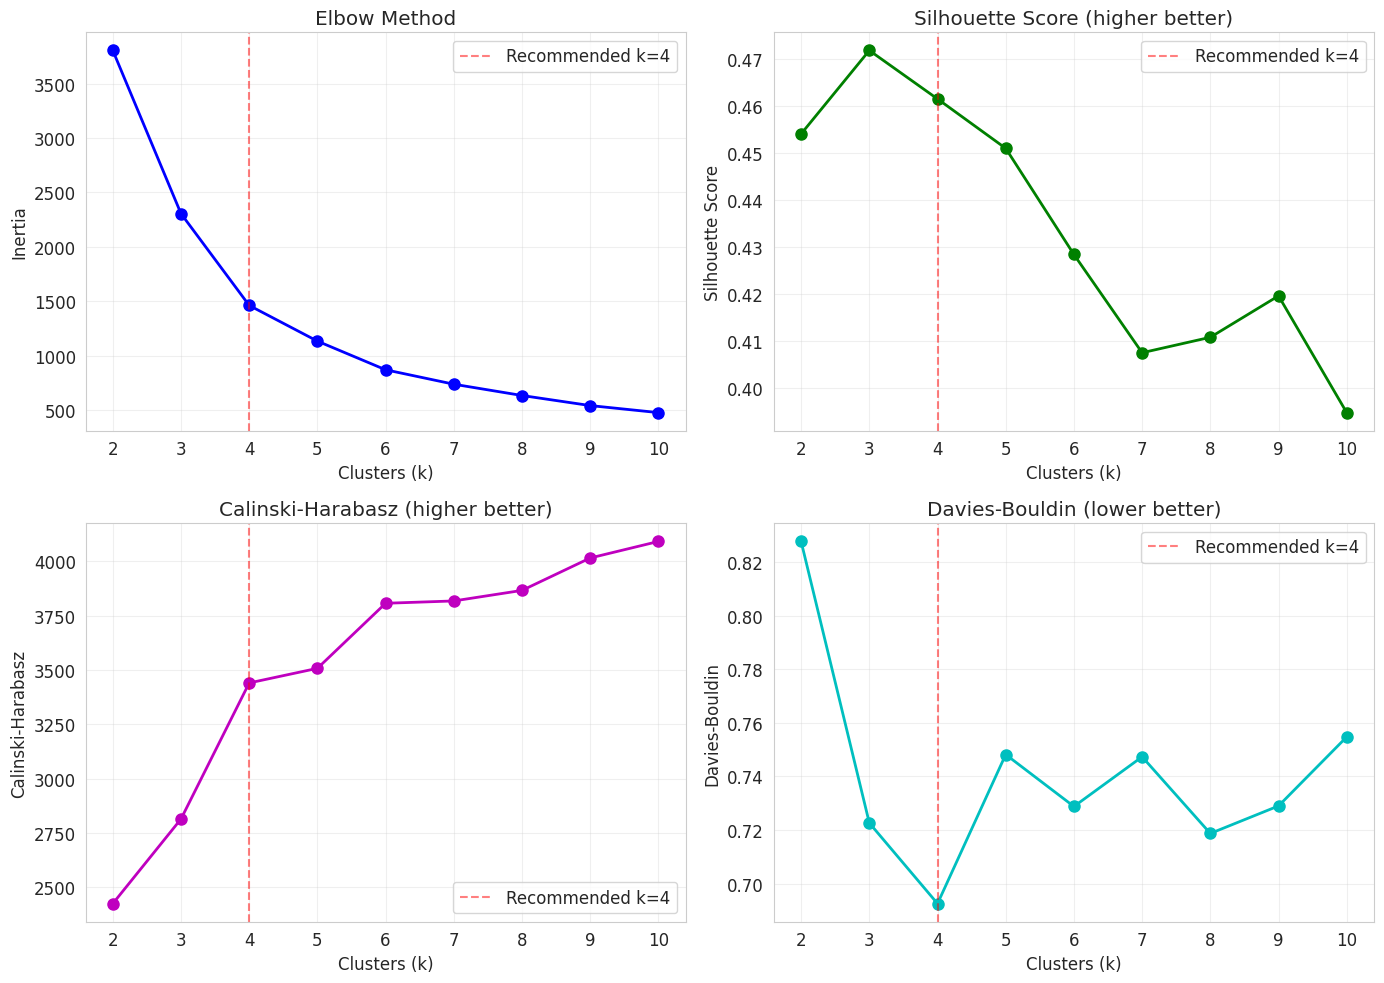

Recommended k = 4


In [ ]:
# FIND OPTIMAL CLUSTERS

inertia = []
silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0,0].axvline(4, color='red', linestyle='--', alpha=0.5, label='Recommended k=4')
axes[0,0].set_xlabel('Clusters (k)'); axes[0,0].set_ylabel('Inertia')
axes[0,0].set_title('Elbow Method'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0,1].axvline(4, color='red', linestyle='--', alpha=0.5, label='Recommended k=4')
axes[0,1].set_xlabel('Clusters (k)'); axes[0,1].set_ylabel('Silhouette Score')
axes[0,1].set_title('Silhouette Score (higher better)'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(K_range, calinski_scores, 'mo-', linewidth=2, markersize=8)
axes[1,0].axvline(4, color='red', linestyle='--', alpha=0.5, label='Recommended k=4')
axes[1,0].set_xlabel('Clusters (k)'); axes[1,0].set_ylabel('Calinski-Harabasz')
axes[1,0].set_title('Calinski-Harabasz (higher better)'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(K_range, davies_bouldin_scores, 'co-', linewidth=2, markersize=8)
axes[1,1].axvline(4, color='red', linestyle='--', alpha=0.5, label='Recommended k=4')
axes[1,1].set_xlabel('Clusters (k)'); axes[1,1].set_ylabel('Davies-Bouldin')
axes[1,1].set_title('Davies-Bouldin (lower better)'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

optimal_k = 4
print(f"Recommended k = {optimal_k}")

In [ ]:
# CLUSTERING & SEGMENT PROFILING

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Segment'] = kmeans.fit_predict(X_scaled)

print("=== CLUSTER DISTRIBUTION ===")
print(rfm['Segment'].value_counts().sort_index())

# Detailed profiles
segment_profile = rfm.groupby('Segment').agg({
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median'],
    'TotalItems': ['mean', 'median'],
    'AvgBasketSize': ['mean', 'median'],
    'BulkRatio': ['mean', 'median'],
    'PreferredCategory': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Mixed',
    'Segment': 'count'
}).round(2)

segment_profile.columns = ['Recency_Mean', 'Recency_Median',
                           'Frequency_Mean', 'Frequency_Median',
                           'Monetary_Mean', 'Monetary_Median',
                           'Items_Mean', 'Items_Median',
                           'Basket_Mean', 'Basket_Median',
                           'BulkRatio_Mean', 'BulkRatio_Median',
                           'TopCategory', 'Count']

print("\n=== SEGMENT PROFILES ===")
print(segment_profile)

# Name segments
segment_names = {
    0: 'New & Infrequent (Low R, Low F, Low M)',
    1: 'Loyal (High F, High M)',
    2: 'At Risk (High R, Low F)',
    3: 'Potential Loyal (Moderate F, Moderate M)'
}
rfm['Segment_Name'] = rfm['Segment'].map(segment_names)
print("\nSegment breakdown:")
print(rfm['Segment_Name'].value_counts())

=== CLUSTER DISTRIBUTION ===
Segment
0     541
1     808
2     149
3    1002
Name: count, dtype: int64

=== SEGMENT PROFILES ===
         Recency_Mean  Recency_Median  Frequency_Mean  Frequency_Median  \
Segment                                                                   
0                2.41             2.0          682.18             661.0   
1               13.64            11.0           77.66              69.0   
2               61.61            56.0           48.58              44.0   
3                4.84             4.0          271.50             262.5   

         Monetary_Mean  Monetary_Median  Items_Mean  Items_Median  \
Segment                                                             
0          15270114.79       14683615.0     2654.41        2570.0   
1           1685674.92        1551240.5      298.97         271.5   
2           1093766.50         942208.0      193.83         163.0   
3           6058076.37        5787770.0     1064.67        1017.5   

     

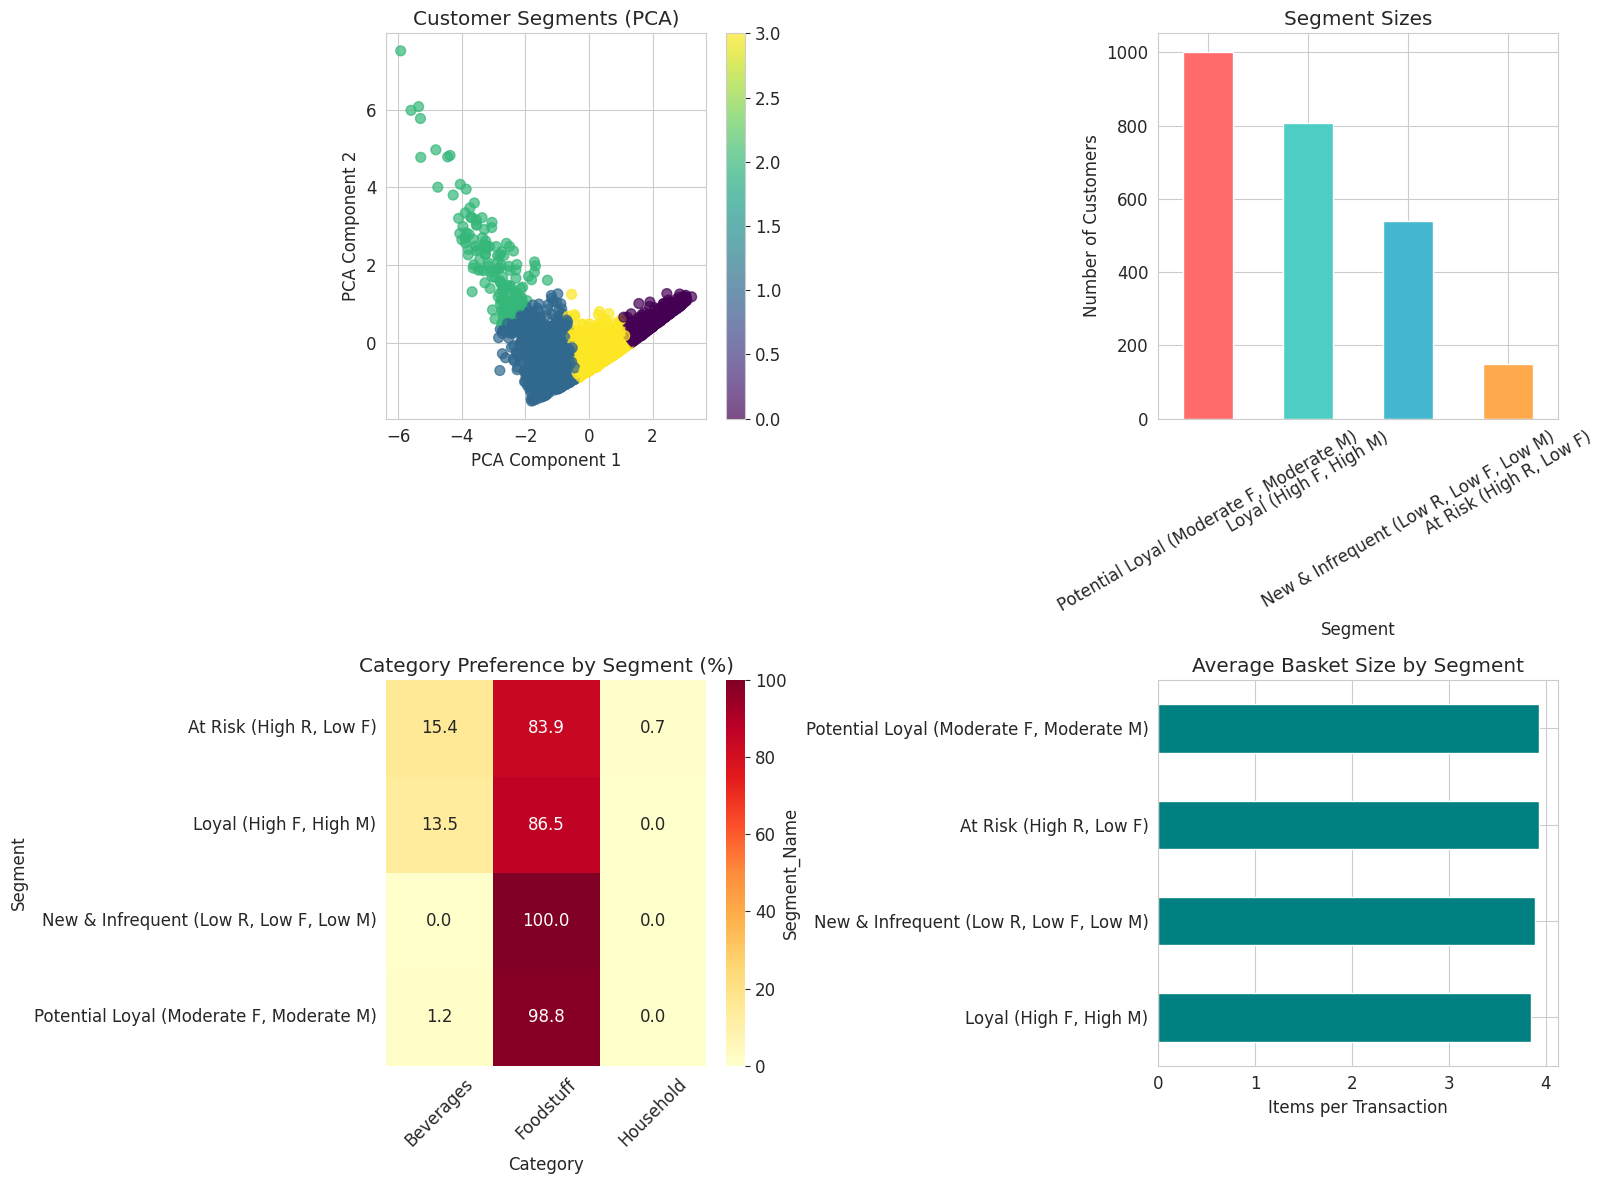

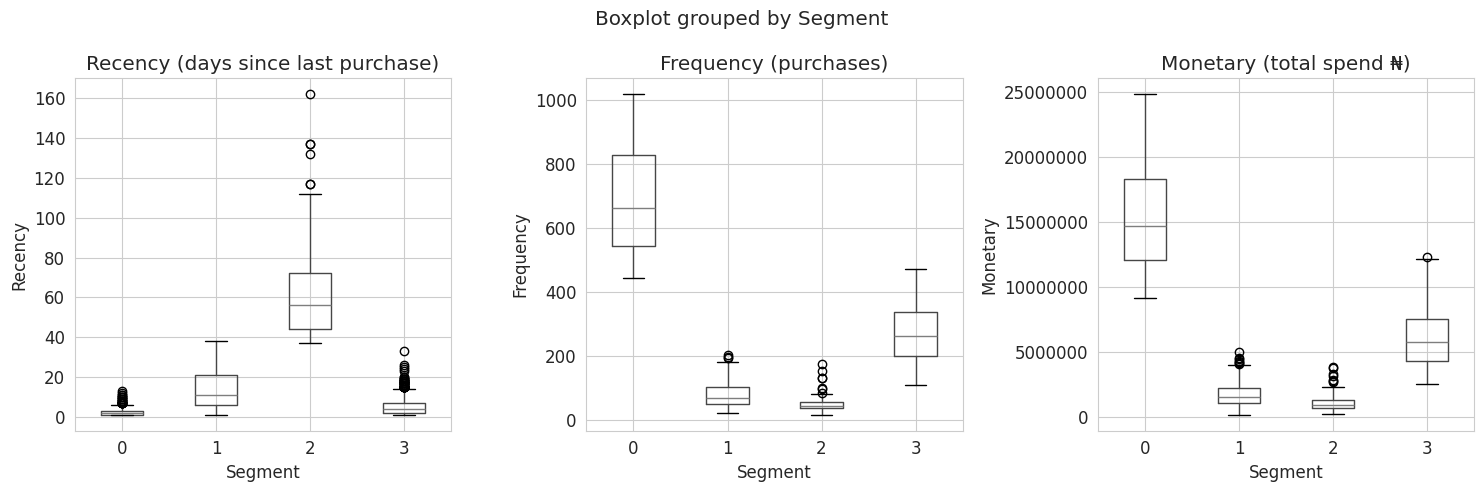

All visualizations saved


In [ ]:
# ENHANCED VISUALIZATIONS PER SEGMENT

# 1. PCA Projection
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. PCA plot
scatter = axes[0,0].scatter(rfm_pca[:,0], rfm_pca[:,1],
                            c=rfm['Segment'], cmap='viridis', alpha=0.7, s=50)
axes[0,0].set_xlabel('PCA Component 1')
axes[0,0].set_ylabel('PCA Component 2')
axes[0,0].set_title('Customer Segments (PCA)')
plt.colorbar(scatter, ax=axes[0,0])

# 2. Segment sizes (bar)
seg_counts = rfm['Segment_Name'].value_counts()
seg_counts.plot(kind='bar', ax=axes[0,1], color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#ffa94d'])
axes[0,1].set_title('Segment Sizes')
axes[0,1].set_xlabel('Segment')
axes[0,1].set_ylabel('Number of Customers')
axes[0,1].tick_params(axis='x', rotation=30)

# 3. Heatmap: Category Preference per Segment
# Build a cross-tab of Segment vs PreferredCategory
cat_seg = pd.crosstab(rfm['Segment_Name'], rfm['PreferredCategory'], normalize='index') * 100
sns.heatmap(cat_seg, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1,0])
axes[1,0].set_title('Category Preference by Segment (%)')
axes[1,0].set_xlabel('Category')
axes[1,0].set_ylabel('Segment')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Average Basket Size per Segment
avg_basket = rfm.groupby('Segment_Name')['AvgBasketSize'].mean().sort_values()
avg_basket.plot(kind='barh', ax=axes[1,1], color='teal')
axes[1,1].set_title('Average Basket Size by Segment')
axes[1,1].set_xlabel('Items per Transaction')

plt.tight_layout()
plt.savefig('enhanced_segment_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional: Boxplots for RFM
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['Recency', 'Frequency', 'Monetary']
titles = ['Recency (days since last purchase)', 'Frequency (purchases)', 'Monetary (total spend ₦)']
for i, (metric, title) in enumerate(zip(metrics, titles)):
    rfm.boxplot(column=metric, by='Segment', ax=axes[i])
    axes[i].set_title(title)
    axes[i].set_xlabel('Segment')
    axes[i].set_ylabel(metric)
    if metric == 'Monetary':
        axes[i].ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.savefig('rfm_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("All visualizations saved")

In [ ]:

# BUSINESS INSIGHTS & RECOMMENDATIONS
print("=" * 70)
print("RETAIL CUSTOMER SEGMENTATION - EXECUTIVE SUMMARY")
print("=" * 70)
print(f"Alheri Supermarket | Period: 2025-2026 | Customers: {len(rfm):,}")
print("=" * 70)

for seg_id in sorted(rfm['Segment'].unique()):
    seg_data = rfm[rfm['Segment'] == seg_id]
    seg_name = segment_names[seg_id]
    print(f"\n{seg_name}")
    print("-" * 50)
    print(f"  Size: {len(seg_data):,} customers ({len(seg_data)/len(rfm)*100:.1f}%)")
    print(f"  Avg Recency: {seg_data['Recency'].mean():.1f} days")
    print(f"  Avg Frequency: {seg_data['Frequency'].mean():.1f} purchases")
    print(f"  Avg Spend: ₦{seg_data['Monetary'].mean():,.2f}")
    print(f"  Avg Basket: {seg_data['AvgBasketSize'].mean():.1f} items")
    print(f"  Bulk Ratio: {seg_data['BulkRatio'].mean():.2f}")
    print(f"  Top Category: {seg_data['PreferredCategory'].mode()[0]}")

    # Recommendations
    if seg_id == 0:
        print("  Strategy:")
        print("     - Welcome offers and first-purchase discounts")
        print("     - Email nurturing to encourage repeat visits")
        print("     - Cross-sell with popular items from their category")
    elif seg_id == 1:
        print("  Strategy:")
        print("     - VIP loyalty program with exclusive access")
        print("     - Personal shopping assistance")
        print("     - Early access to new products and promotions")
    elif seg_id == 2:
        print("  Strategy:")
        print("     - Win-back campaigns with special offers")
        print("     - Survey to understand why they stopped visiting")
        print("     - Re-engage via SMS/WhatsApp with personalized deals")
    elif seg_id == 3:
        print("  Strategy:")
        print("     - Upsell/cross-sell based on their preferred category")
        print("     - Invite to loyalty program")
        print("     - Encourage larger basket sizes via bundle deals")

print("\n" + "=" * 70)
print("KEY RECOMMENDATIONS")
print("=" * 70)
print("1. Focus 60% of marketing budget on Champions & Potential Loyal segments")
print("2. Implement a loyalty program for the Champion segment (≈{:.0f} customers)".format(rfm[rfm['Segment']==1].shape[0]))
print("3. Run re-engagement campaigns for At Risk customers (≈{:.0f} customers)".format(rfm[rfm['Segment']==2].shape[0]))
print("4. Nurture New customers with targeted welcome sequences")
print("5. Leverage category preferences for personalized promotions")
print("6. Bulk buyers (≈{:.1f}% of transactions) should be offered bulk discounts".format(df['IsBulk'].sum()/len(df)*100))

RETAIL CUSTOMER SEGMENTATION - EXECUTIVE SUMMARY
Alheri Supermarket | Period: 2025-2026 | Customers: 2,500

New & Infrequent (Low R, Low F, Low M)
--------------------------------------------------
  Size: 541 customers (21.6%)
  Avg Recency: 2.4 days
  Avg Frequency: 682.2 purchases
  Avg Spend: ₦15,270,114.79
  Avg Basket: 3.9 items
  Bulk Ratio: 0.03
  Top Category: Foodstuff
  Strategy:
     - Welcome offers and first-purchase discounts
     - Email nurturing to encourage repeat visits
     - Cross-sell with popular items from their category

Loyal (High F, High M)
--------------------------------------------------
  Size: 808 customers (32.3%)
  Avg Recency: 13.6 days
  Avg Frequency: 77.7 purchases
  Avg Spend: ₦1,685,674.92
  Avg Basket: 3.8 items
  Bulk Ratio: 0.03
  Top Category: Foodstuff
  Strategy:
     - VIP loyalty program with exclusive access
     - Personal shopping assistance
     - Early access to new products and promotions

At Risk (High R, Low F)
-----------------

In [ ]:
# EXPORTING RESULTS

# Segmented customers (with all RFM metrics)
rfm.to_csv('customer_segments.csv')
print("customer_segments.csv saved")

# Segment profiles
segment_profile.to_csv('segment_profiles.csv')
print("segment_profiles.csv saved")

# Summary stats
summary_stats = {
    'Total_Customers': len(rfm),
    'Optimal_Clusters': optimal_k,
    'Silhouette_Score': silhouette_score(X_scaled, rfm['Segment']),
    'Average_Recency': rfm['Recency'].mean(),
    'Average_Frequency': rfm['Frequency'].mean(),
    'Average_Monetary': rfm['Monetary'].mean(),
    'Total_Revenue': rfm['Monetary'].sum(),
    'Avg_Basket_Size': rfm['AvgBasketSize'].mean(),
    'Bulk_Purchase_Ratio': df['IsBulk'].sum() / len(df)
}
pd.DataFrame([summary_stats]).to_csv('project_summary.csv', index=False)
print("project_summary.csv saved")

print("\n All outputs saved successfully")

customer_segments.csv saved
segment_profiles.csv saved
project_summary.csv saved

 All outputs saved successfully
